## Object Detection and Tracking

In this project, we use a traffic video as input.

- **OpenCV** reads the video frame by frame.
- A **pre-trained YOLO11n model** detects objects such as people, cars, buses, bicycles, and motorcycles.
- We use a **confidence threshold of 0.4** to ignore very weak detections.
- **Deep SORT** tracks the detected objects across consecutive frames.
- Each tracked object gets a unique **tracking ID**.
- **Bounding boxes, object labels, and tracking IDs** are drawn on each frame.
- The processed frames are saved as one **annotated output video**.

No dataset or model training is required because we are using a pre-trained YOLO model.

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 6.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving traffic_video.mp4 to traffic_video.mp4


In [ ]:
import os

video_path = list(uploaded.keys())[0]

print("Video:", video_path)
print("File size:", round(os.path.getsize(video_path) / (1024 * 1024), 2), "MB")

Video: traffic_video.mp4
File size: 89.28 MB


In [ ]:
import cv2

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print("Resolution:", width, "x", height)
print("FPS:", fps)
print("Total frames:", frame_count)
print("Duration:", round(duration, 2), "seconds")

cap.release()

Resolution: 2560 x 1440
FPS: 25.0
Total frames: 1413
Duration: 56.52 seconds


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
YOLO model loaded successfully!


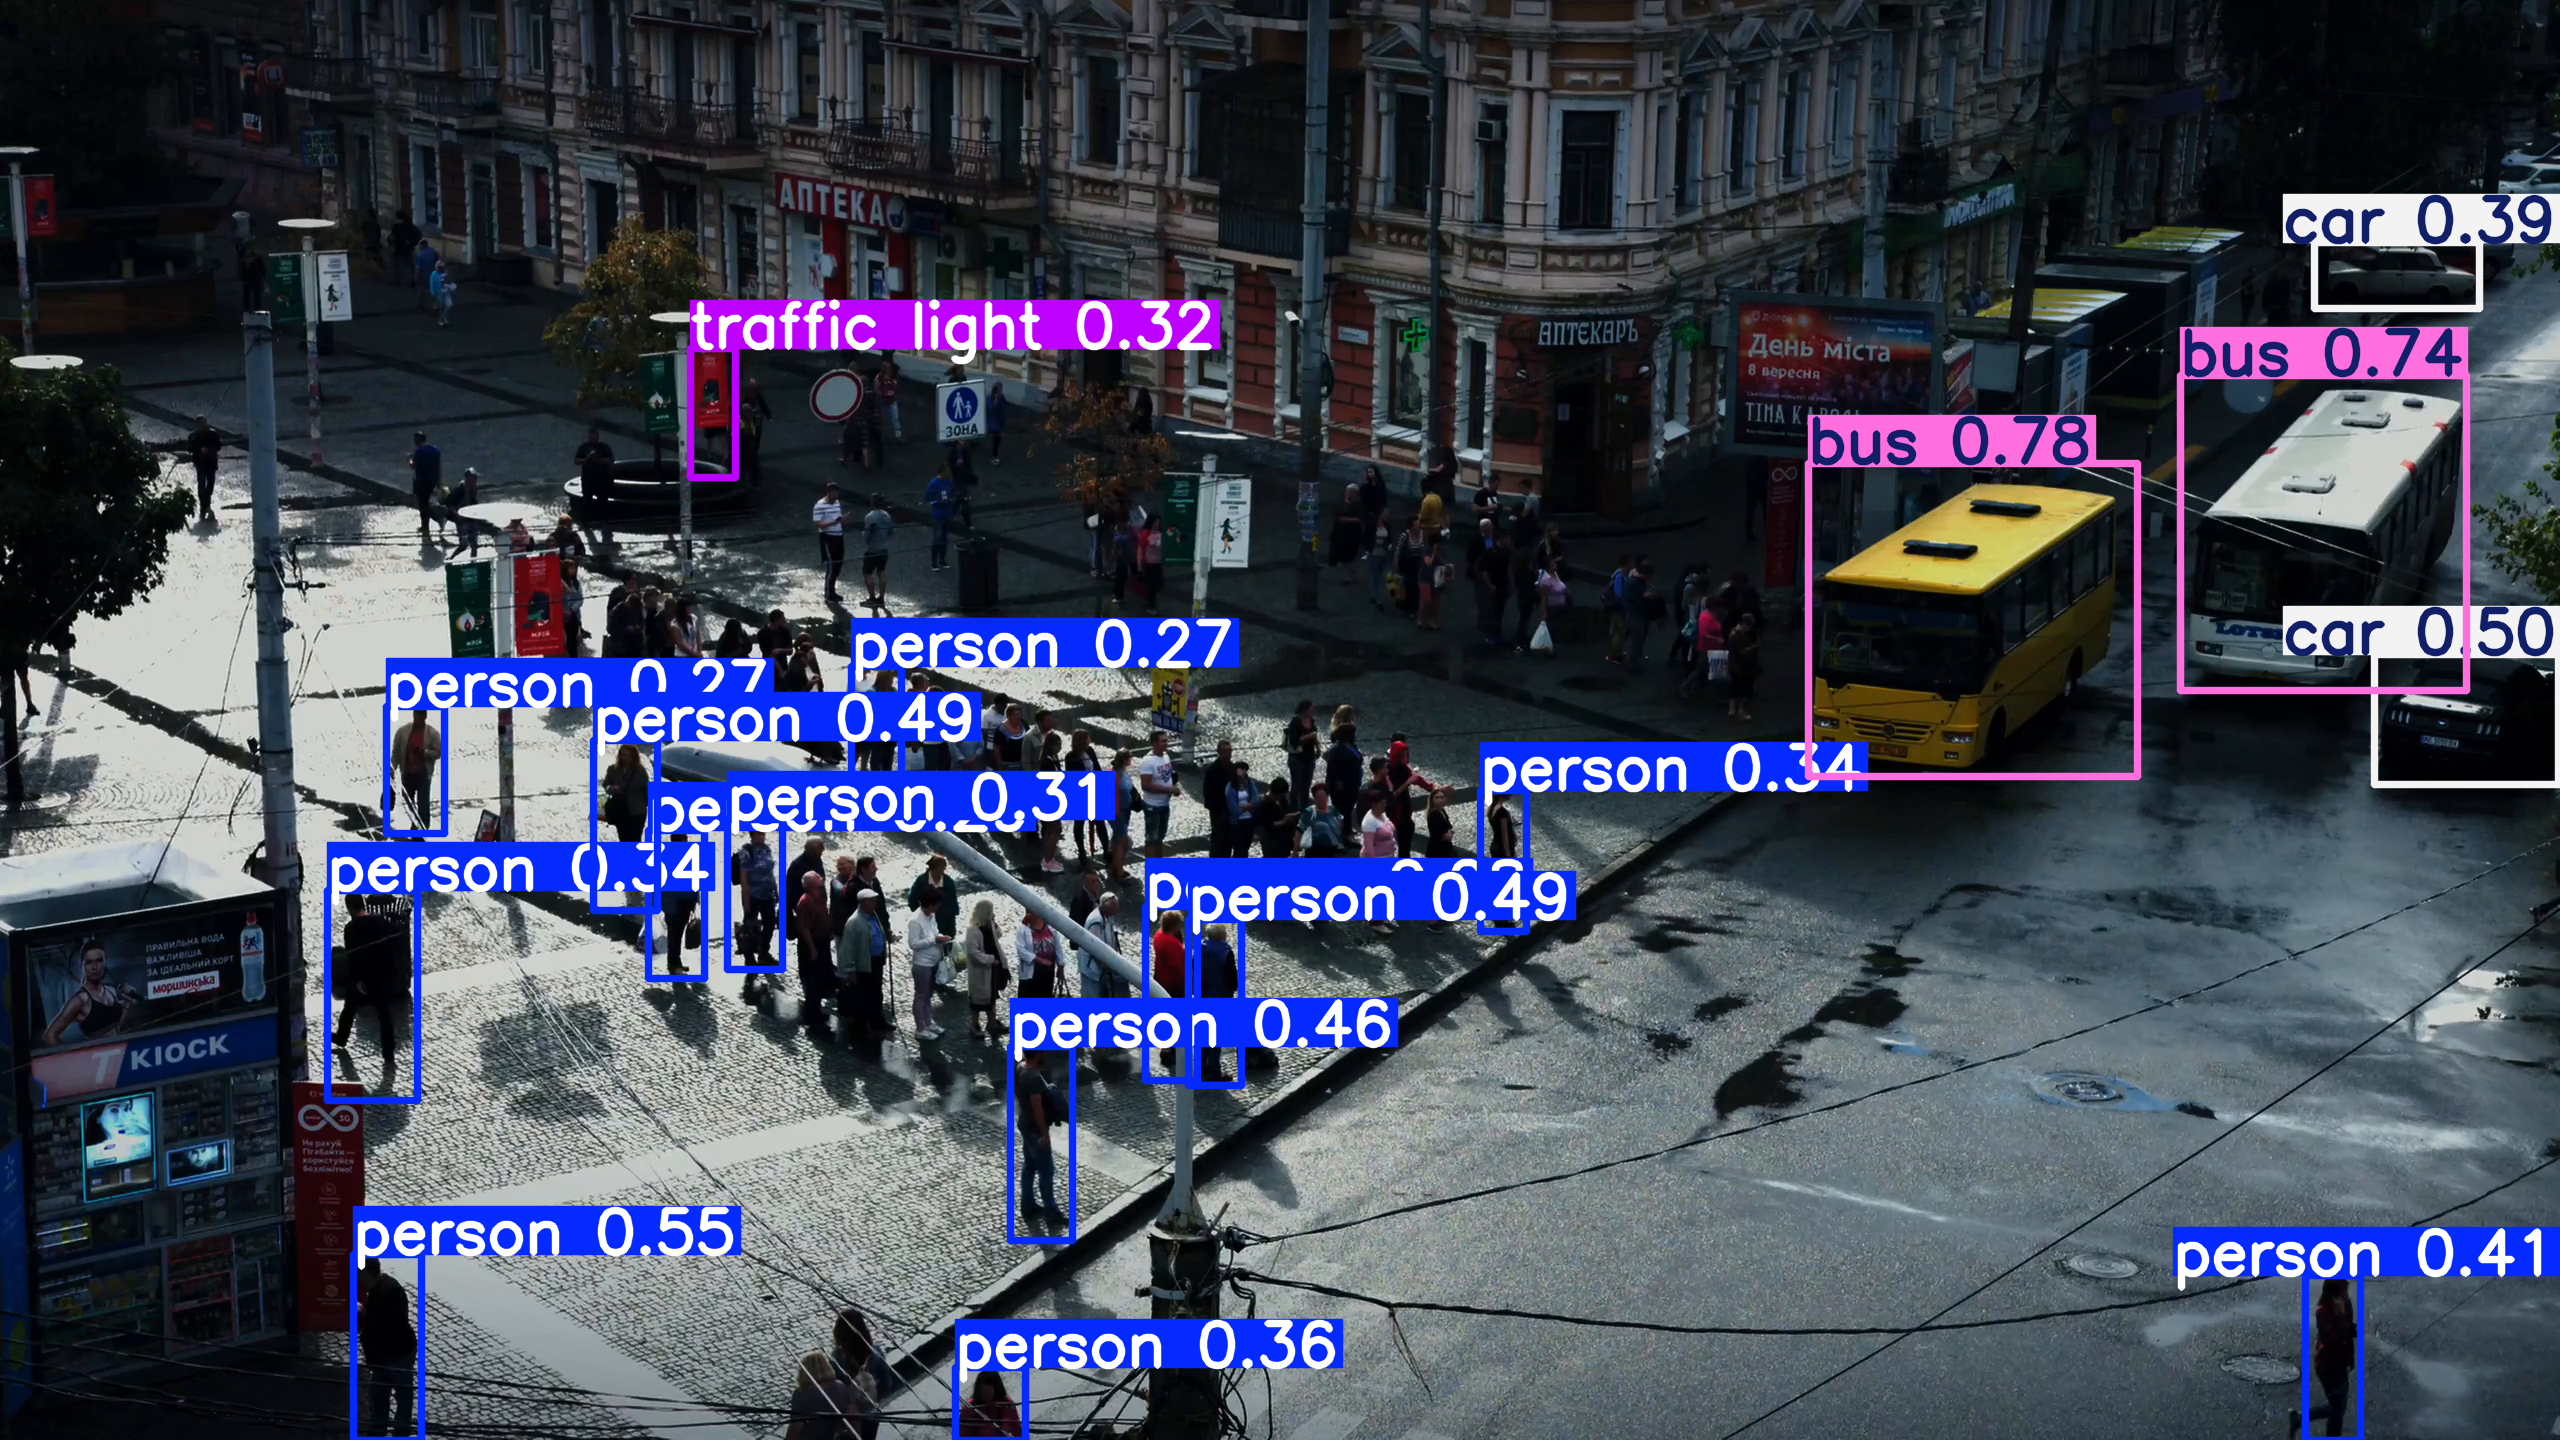

In [ ]:
import cv2
from IPython.display import display
from PIL import Image

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()
cap.release()

if ret:
    results = model(frame, verbose=False)

    annotated_frame = results[0].plot()

    display(Image.fromarray(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)))
else:
    print("Could not read the video.")

In [ ]:
!pip install -q deep-sort-realtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 36.2 MB/s eta 0:00:00


In [ ]:
# Object classes we want to detect and track
selected_classes = {
    0: "person",
    1: "bicycle",
    2: "car",
    3: "motorcycle",
    5: "bus"
}

# Convert class IDs into a list for YOLO
class_ids = list(selected_classes.keys())

print("Objects we will track:")
for class_id, name in selected_classes.items():
    print(f"{class_id}: {name}")

print("\nClass IDs:", class_ids)

Objects we will track:
0: person
1: bicycle
2: car
3: motorcycle
5: bus

Class IDs: [0, 1, 2, 3, 5]


In [ ]:
import cv2
import torch
from deep_sort_realtime.deepsort_tracker import DeepSort

# -----------------------------
# 1. Create Deep SORT tracker
# -----------------------------
tracker = DeepSort(
    max_age=30,
    n_init=3,
    max_iou_distance=0.7
)

# -----------------------------
# 2. Open input video
# -----------------------------
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Could not open the video.")

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Resolution: {width} x {height}")
print(f"FPS: {fps}")
print(f"Total frames: {total_frames}")

# -----------------------------
# 3. Create output video
# -----------------------------
output_path = "/content/traffic_tracked.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

print("Tracker and video writer initialized.")

Resolution: 2560 x 1440
FPS: 25.0
Total frames: 1413
Tracker and video writer initialized.


In [ ]:
import cv2
import time
import gc

# Confidence threshold
CONF_THRESHOLD = 0.40

# Start timer
start_time = time.time()

frame_number = 0

print("Starting detection + Deep SORT tracking...")
print("Processing frames one at a time.\n")

while True:
    # -----------------------------
    # Read ONE frame
    # -----------------------------
    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # -----------------------------
    # YOLO detection
    # -----------------------------
    results = model(
        frame,
        classes=class_ids,
        conf=CONF_THRESHOLD,
        verbose=False
    )

    detections = []

    # -----------------------------
    # Extract YOLO detections
    # -----------------------------
    result = results[0]

    if result.boxes is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        confidences = result.boxes.conf.cpu().numpy()
        class_indices = result.boxes.cls.cpu().numpy().astype(int)

        for box, confidence, class_id in zip(
            boxes, confidences, class_indices
        ):

            x1, y1, x2, y2 = box

            # Convert to Deep SORT format:
            # [left, top, width, height]
            w = x2 - x1
            h = y2 - y1

            detections.append(
                (
                    [float(x1), float(y1), float(w), float(h)],
                    float(confidence),
                    selected_classes[class_id]
                )
            )

    # -----------------------------
    # Deep SORT tracking
    # -----------------------------
    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    # -----------------------------
    # Draw tracking results
    # -----------------------------
    for track in tracks:

        if not track.is_confirmed():
            continue

        track_id = track.track_id

        ltrb = track.to_ltrb()

        x1, y1, x2, y2 = map(int, ltrb)

        class_name = track.get_det_class()

        # Draw bounding box
        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Label
        label = f"{class_name} | ID: {track_id}"

        cv2.putText(
            frame,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    # -----------------------------
    # Write ONE processed frame
    # -----------------------------
    out.write(frame)

    # -----------------------------
    # Progress display
    # -----------------------------
    if frame_number % 50 == 0 or frame_number == total_frames:
        elapsed = time.time() - start_time
        progress = (frame_number / total_frames) * 100

        print(
            f"Processed: {frame_number}/{total_frames} "
            f"({progress:.1f}%) | "
            f"Time: {elapsed:.1f}s"
        )

    # Remove references to reduce memory usage
    del results
    del frame

# -----------------------------
# Finish
# -----------------------------
cap.release()
out.release()

gc.collect()

elapsed = time.time() - start_time

print("\nProcessing complete!")
print(f"Frames processed: {frame_number}")
print(f"Time taken: {elapsed / 60:.2f} minutes")
print(f"Output saved to: {output_path}")

Starting detection + Deep SORT tracking...
Processing frames one at a time.

Processed: 50/1413 (3.5%) | Time: 25.6s
Processed: 100/1413 (7.1%) | Time: 49.0s
Processed: 150/1413 (10.6%) | Time: 72.7s
Processed: 200/1413 (14.2%) | Time: 95.5s
Processed: 250/1413 (17.7%) | Time: 123.9s
Processed: 300/1413 (21.2%) | Time: 152.9s
Processed: 350/1413 (24.8%) | Time: 179.8s
Processed: 400/1413 (28.3%) | Time: 204.0s
Processed: 450/1413 (31.8%) | Time: 229.1s
Processed: 500/1413 (35.4%) | Time: 252.7s
Processed: 550/1413 (38.9%) | Time: 273.3s
Processed: 600/1413 (42.5%) | Time: 299.7s
Processed: 650/1413 (46.0%) | Time: 330.8s
Processed: 700/1413 (49.5%) | Time: 360.2s
Processed: 750/1413 (53.1%) | Time: 389.1s
Processed: 800/1413 (56.6%) | Time: 416.9s
Processed: 850/1413 (60.2%) | Time: 451.7s
Processed: 900/1413 (63.7%) | Time: 480.7s
Processed: 950/1413 (67.2%) | Time: 510.1s
Processed: 1000/1413 (70.8%) | Time: 537.0s
Processed: 1050/1413 (74.3%) | Time: 566.1s
Processed: 1100/1413 (77.

In [ ]:
import os

print("Input:", round(os.path.getsize(video_path) / (1024**2), 2), "MB")
print("Output:", round(os.path.getsize(output_path) / (1024**2), 2), "MB")

Input: 89.28 MB
Output: 293.76 MB
